In [1]:
# ======================================================================
# CELL 1: Windows Local Setup (NVIDIA GPU)
#
# Recommended:
# 1) Create a fresh Python 3.11 environment.
#    Example with conda:
#       conda create -n e2_win python=3.11 -y
#       conda activate e2_win
#
# 2) Install PyTorch using the current official Windows + CUDA command
#    from the PyTorch "Get Started" page.
#    Then install the remaining dependencies:
#       pip install gymnasium[atari] ale-py numpy pandas matplotlib scipy scikit-learn jupyter ipykernel
#
# 3) Optional: register this environment as a Jupyter kernel
#       python -m ipykernel install --user --name e2_win --display-name "E2 Windows GPU"
#
# 4) Open this notebook and run cells from top to bottom.
#
# Notes:
# - This notebook targets local Windows machines with an NVIDIA GPU.
# - The first torchvision ResNet-18 load may download pretrained ImageNet weights once.
# ======================================================================

print("Windows GPU notebook loaded. Make sure your CUDA-enabled PyTorch build is installed first.")

Windows GPU notebook loaded. Make sure your CUDA-enabled PyTorch build is installed first.


In [2]:
# ======================================================================
# CELL 2: Imports, Constants, Paths, and Device Selection
# ======================================================================

from pathlib import Path
import os
import sys
import time
import json
import math
import random
import platform
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions.categorical import Categorical
from torchvision import models

import gymnasium as gym
import ale_py
from gymnasium.wrappers import AtariPreprocessing, RecordEpisodeStatistics
try:
    from gymnasium.wrappers import FrameStackObservation as FrameStackWrapper
except ImportError:
    from gymnasium.wrappers import FrameStack as FrameStackWrapper

gym.register_envs(ale_py)

# -----------------------------
# Experiment configuration
# -----------------------------
ENV_ID = "PongNoFrameskip-v4"
FRAME_SKIP = 4
NUM_STACK = 4

SWEEP_SEED = 0
FINAL_SEEDS = [0, 1, 2, 3, 4]

LR_CANDIDATES = [1e-4, 2.5e-4, 1e-3]
CLIP_CANDIDATES = [0.1, 0.2]

SWEEP_TOTAL_TIMESTEPS = 1_000_000
FINAL_TOTAL_TIMESTEPS = 2_000_000

# Use 8 * 125 = 1000 steps/update so both 1M and 2M are exactly divisible.
NUM_ENVS = 8
NUM_STEPS = 125
NUM_MINIBATCHES = 4

GAMMA = 0.99
GAE_LAMBDA = 0.95
UPDATE_EPOCHS = 4
ENT_COEF = 0.01
VF_COEF = 0.5
MAX_GRAD_NORM = 0.5
TARGET_KL = None

PREFERRED_ACCELERATOR = 'cuda'
PROJECT_DIRNAME = 'E2_experiment_windows_gpu'

assert (NUM_ENVS * NUM_STEPS) == 1000
assert SWEEP_TOTAL_TIMESTEPS % (NUM_ENVS * NUM_STEPS) == 0
assert FINAL_TOTAL_TIMESTEPS % (NUM_ENVS * NUM_STEPS) == 0

project_root = Path(f"./{PROJECT_DIRNAME}")
for sub in ["checkpoints", "logs", "plots", "tables"]:
    (project_root / "outputs" / sub).mkdir(parents=True, exist_ok=True)

def get_runtime_device(preferred=PREFERRED_ACCELERATOR):
    if preferred == "cuda":
        if torch.cuda.is_available():
            return torch.device("cuda")
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        return torch.device("cpu")
    if preferred == "mps":
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        if torch.cuda.is_available():
            return torch.device("cuda")
        return torch.device("cpu")
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_runtime_device()

print("Platform:", platform.platform())
print("Python:", sys.version.split()[0])
print("Torch:", torch.__version__)
print("Preferred accelerator:", PREFERRED_ACCELERATOR)
print("Resolved device:", device)

if device.type == "cuda":
    print("CUDA available:", torch.cuda.is_available())
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")
elif device.type == "mps":
    print("MPS available:", torch.backends.mps.is_available())
    print("Apple Metal backend is active.")
else:
    print("Running on CPU.")

print("Project root:", project_root.resolve())

Platform: Windows-10-10.0.26200-SP0
Python: 3.11.15
Torch: 2.12.0.dev20260327+cu128
Preferred accelerator: cuda
Resolved device: cuda
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Laptop GPU
VRAM: 7.96 GB
Project root: C:\Users\zhang\Desktop\ELG5214\E2\E2_experiment_windows_gpu


In [3]:
# ======================================================================
# CELL 3: Utility Functions and Environment Construction
# ======================================================================

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def safe_empty_cache():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    if hasattr(torch, "mps") and hasattr(torch.mps, "empty_cache"):
        try:
            torch.mps.empty_cache()
        except Exception:
            pass


class FireResetWrapper(gym.Wrapper):
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        try:
            meanings = self.unwrapped.get_action_meanings()
            if "FIRE" in meanings:
                fire_action = meanings.index("FIRE")
                obs, _, terminated, truncated, info = self.env.step(fire_action)
                if terminated or truncated:
                    obs, info = self.env.reset(**kwargs)
        except Exception:
            pass
        return obs, info


def make_env(seed: int, idx: int):
    def thunk():
        env = gym.make(ENV_ID, render_mode=None, frameskip=1)
        env = AtariPreprocessing(
            env,
            frame_skip=FRAME_SKIP,
            screen_size=84,
            grayscale_obs=True,
            scale_obs=False,
        )
        env = FrameStackWrapper(env, NUM_STACK)
        env = FireResetWrapper(env)
        env = RecordEpisodeStatistics(env)

        try:
            env.action_space.seed(seed + idx)
            env.observation_space.seed(seed + idx)
        except Exception:
            pass
        return env
    return thunk


def load_checkpoint_state_dict(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=map_location)


test_env = make_env(0, 0)()
obs, _ = test_env.reset(seed=0)
obs_np = np.asarray(obs)

print("ENV_ID:", ENV_ID)
print("obs shape:", obs_np.shape, "| dtype:", obs_np.dtype)
print("action_dim:", test_env.action_space.n)
print("action meanings:", test_env.unwrapped.get_action_meanings())

action_dim = test_env.action_space.n
test_env.close()

ENV_ID: PongNoFrameskip-v4
obs shape: (4, 84, 84) | dtype: uint8
action_dim: 6
action meanings: ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']


In [4]:
# ======================================================================
# CELL 4: Model Definition — Frozen ResNet-18 (NO GAP) + PPO Agent
# ======================================================================

class FrozenFramewiseResNet18(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(backbone.children())[:-2])
        for p in self.backbone.parameters():
            p.requires_grad = False
        self.backbone.eval()

        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        self.register_buffer("mean", mean)
        self.register_buffer("std", std)

    def forward(self, obs):
        B = obs.shape[0]
        x = obs.float() / 255.0
        x = x.reshape(B * NUM_STACK, 1, 84, 84).repeat(1, 3, 1, 1)
        x = (x - self.mean) / self.std
        with torch.no_grad():
            z = self.backbone(x)                      # (B*4, 512, 3, 3)
        z = z.view(B, NUM_STACK, 512, 3, 3)          # (B, 4, 512, 3, 3)
        return z


class E2Agent(nn.Module):
    def __init__(self, action_dim):
        super().__init__()
        self.encoder = FrozenFramewiseResNet18()
        self.projection = nn.Sequential(
            nn.Linear(NUM_STACK * 512 * 3 * 3, 512),
            nn.ReLU(),
        )
        self.shared = nn.Sequential(
            nn.Linear(512, 512),
            nn.ReLU(),
        )
        self.actor = nn.Linear(512, action_dim)
        self.critic = nn.Linear(512, 1)

    def forward_features(self, obs):
        B = obs.shape[0]
        z = self.encoder(obs)                        # (B, 4, 512, 3, 3)
        z = z.reshape(B, -1)                         # (B, 18432)
        h = self.projection(z)                       # (B, 512)
        h = self.shared(h)                           # (B, 512)
        return h

    def get_value(self, obs):
        return self.critic(self.forward_features(obs)).squeeze(-1)

    def get_action_and_value(self, obs, action=None):
        h = self.forward_features(obs)
        logits = self.actor(h)
        dist = Categorical(logits=logits)
        if action is None:
            action = dist.sample()
        value = self.critic(h).squeeze(-1)
        return action, dist.log_prob(action), dist.entropy(), value

In [5]:
# ======================================================================
# CELL 5: Smoke Test — Model Shapes and Parameter Counts
# ======================================================================

set_seed(0)
_agent = E2Agent(action_dim=action_dim).to(device)
_dummy = torch.randint(0, 256, (8, NUM_STACK, 84, 84), dtype=torch.uint8, device=device)

a, lp, ent, v = _agent.get_action_and_value(_dummy)
print("action:", a.shape, "| logprob:", lp.shape, "| entropy:", ent.shape, "| value:", v.shape)

total_p = sum(p.numel() for p in _agent.parameters())
train_p = sum(p.numel() for p in _agent.parameters() if p.requires_grad)

print(f"Total params:     {total_p:>12,}")
print(f"Trainable params: {train_p:>12,}")
print(f"Frozen params:    {total_p - train_p:>12,}")

if device.type == "cuda":
    print(f"VRAM used:     {torch.cuda.memory_allocated()/1024**2:>10.0f} MB")
    print(f"VRAM reserved: {torch.cuda.memory_reserved()/1024**2:>10.0f} MB")

del _agent, _dummy
safe_empty_cache()

action: torch.Size([8]) | logprob: torch.Size([8]) | entropy: torch.Size([8]) | value: torch.Size([8])
Total params:       20,880,455
Trainable params:    9,703,943
Frozen params:      11,176,512
VRAM used:            113 MB
VRAM reserved:        168 MB


In [6]:
# ======================================================================
# CELL 6: PPO Training Function
# ======================================================================

def train_e2(agent, optimizer, config):
    set_seed(config["seed"])
    dev = torch.device(config["device"])
    agent.train()
    agent.encoder.backbone.eval()

    ckpt_dir = project_root / "outputs" / "checkpoints" / config["run_name"]
    log_dir = project_root / "outputs" / "logs" / config["run_name"]
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    log_dir.mkdir(parents=True, exist_ok=True)

    NE = config["num_envs"]
    NS = config["num_steps"]
    BS = NE * NS
    assert config["total_timesteps"] % BS == 0, "total_timesteps must be divisible by num_envs*num_steps"
    MBS = BS // config["num_minibatches"]
    assert BS % config["num_minibatches"] == 0, "Batch size must be divisible by num_minibatches"
    NU = config["total_timesteps"] // BS

    envs = gym.vector.SyncVectorEnv([make_env(config["seed"], i) for i in range(NE)])
    obs, _ = envs.reset(seed=[config["seed"] + i for i in range(NE)])

    ep_ret = np.zeros(NE, dtype=np.float32)
    recent = deque(maxlen=20)
    all_ep_returns = []
    log_rows = []
    global_step = 0
    best = -1e9
    t0 = time.time()

    for upd in range(1, NU + 1):
        if config.get("anneal_lr", False):
            frac = 1.0 - (upd - 1.0) / NU
            optimizer.param_groups[0]["lr"] = frac * config["learning_rate"]

        ob = torch.zeros((NS, NE, NUM_STACK, 84, 84), dtype=torch.uint8, device=dev)
        ac = torch.zeros((NS, NE), dtype=torch.long, device=dev)
        lp = torch.zeros((NS, NE), dtype=torch.float32, device=dev)
        rw = torch.zeros((NS, NE), dtype=torch.float32, device=dev)
        dn = torch.zeros((NS, NE), dtype=torch.float32, device=dev)
        vl = torch.zeros((NS, NE), dtype=torch.float32, device=dev)

        for t in range(NS):
            global_step += NE
            obs_t = torch.as_tensor(np.asarray(obs), dtype=torch.uint8, device=dev)
            ob[t] = obs_t

            with torch.no_grad():
                a, l, e, v = agent.get_action_and_value(obs_t)

            ac[t] = a
            lp[t] = l
            vl[t] = v

            next_obs, rew, term, trunc, info = envs.step(a.detach().cpu().numpy())
            done = np.logical_or(term, trunc)

            rw[t] = torch.as_tensor(rew, dtype=torch.float32, device=dev)
            dn[t] = torch.as_tensor(done, dtype=torch.float32, device=dev)

            ep_ret += rew.astype(np.float32)
            for i in range(NE):
                if done[i]:
                    ret_val = float(ep_ret[i])
                    recent.append(ret_val)
                    all_ep_returns.append(ret_val)
                    if ret_val > best:
                        best = ret_val
                        torch.save(agent.state_dict(), ckpt_dir / "best.pt")
                    ep_ret[i] = 0.0

            obs = next_obs

        with torch.no_grad():
            next_value = agent.get_value(torch.as_tensor(np.asarray(obs), dtype=torch.uint8, device=dev))

        adv = torch.zeros_like(rw)
        lastgaelam = torch.zeros(NE, dtype=torch.float32, device=dev)

        for t in reversed(range(NS)):
            next_non_terminal = 1.0 - dn[t]
            next_values = next_value if t == NS - 1 else vl[t + 1]
            delta = rw[t] + config["gamma"] * next_values * next_non_terminal - vl[t]
            lastgaelam = delta + config["gamma"] * config["gae_lambda"] * next_non_terminal * lastgaelam
            adv[t] = lastgaelam

        ret = adv + vl

        b_obs = ob.reshape((-1, NUM_STACK, 84, 84))
        b_act = ac.reshape(-1)
        b_logp = lp.reshape(-1)
        b_adv = adv.reshape(-1)
        b_ret = ret.reshape(-1)
        b_val = vl.reshape(-1)

        b_adv = (b_adv - b_adv.mean()) / (b_adv.std() + 1e-8)

        batch_idx = np.arange(BS)
        clipfracs = []
        approx_kl = torch.tensor(0.0, device=dev)
        pg_loss = torch.tensor(0.0, device=dev)
        v_loss = torch.tensor(0.0, device=dev)
        entropy_loss = torch.tensor(0.0, device=dev)

        early_stop = False
        for epoch in range(config["update_epochs"]):
            np.random.shuffle(batch_idx)
            for start in range(0, BS, MBS):
                mb_idx = batch_idx[start:start + MBS]
                _, newlogp, entropy, newvalue = agent.get_action_and_value(b_obs[mb_idx], b_act[mb_idx])

                logratio = newlogp - b_logp[mb_idx]
                ratio = logratio.exp()

                with torch.no_grad():
                    approx_kl = ((ratio - 1.0) - logratio).mean()
                    clipfracs.append(((ratio - 1.0).abs() > config["clip_coef"]).float().mean().item())

                mb_adv = b_adv[mb_idx]
                pg_loss = torch.max(
                    -mb_adv * ratio,
                    -mb_adv * torch.clamp(ratio, 1 - config["clip_coef"], 1 + config["clip_coef"]),
                ).mean()

                v_loss_unclipped = (newvalue - b_ret[mb_idx]) ** 2
                v_clipped = b_val[mb_idx] + torch.clamp(
                    newvalue - b_val[mb_idx],
                    -config["clip_coef"],
                    config["clip_coef"],
                )
                v_loss_clipped = (v_clipped - b_ret[mb_idx]) ** 2
                v_loss = 0.5 * torch.max(v_loss_unclipped, v_loss_clipped).mean()

                entropy_loss = entropy.mean()
                loss = pg_loss - config["ent_coef"] * entropy_loss + config["vf_coef"] * v_loss

                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    [p for p in agent.parameters() if p.requires_grad],
                    config["max_grad_norm"],
                )
                optimizer.step()
                agent.encoder.backbone.eval()

                if config["target_kl"] is not None and approx_kl > config["target_kl"]:
                    early_stop = True
                    break
            if early_stop:
                break

        if upd % config.get("save_every_updates", 200) == 0:
            torch.save(agent.state_dict(), ckpt_dir / f"ckpt_{upd}.pt")

        elapsed = time.time() - t0
        sps = int(global_step / elapsed) if elapsed > 0 else 0

        row = {
            "update": upd,
            "global_step": global_step,
            "lr": float(optimizer.param_groups[0]["lr"]),
            "pg_loss": float(pg_loss.item()),
            "v_loss": float(v_loss.item()),
            "entropy": float(entropy_loss.item()),
            "approx_kl": float(approx_kl.item()),
            "clipfrac": float(np.mean(clipfracs)) if clipfracs else 0.0,
            "recent_return_mean": float(np.mean(recent)) if recent else np.nan,
            "recent_return_std": float(np.std(recent)) if recent else np.nan,
            "best_return": float(best),
            "sps": sps,
            "elapsed_sec": elapsed,
        }
        log_rows.append(row)

        if upd % 20 == 0 or upd == 1:
            print(
                f"upd={upd:04d}/{NU} "
                f"step={global_step:,} "
                f"ret={row['recent_return_mean']:.2f} "
                f"best={best:.0f} "
                f"pg={row['pg_loss']:.4f} "
                f"ent={row['entropy']:.4f} "
                f"sps={sps}"
            )

    torch.save(agent.state_dict(), ckpt_dir / "final.pt")

    log_df = pd.DataFrame(log_rows)
    log_df.to_csv(log_dir / "train_log.csv", index=False)

    summary = {
        "run_name": config["run_name"],
        "seed": config["seed"],
        "env_id": ENV_ID,
        "total_timesteps": config["total_timesteps"],
        "effective_total_timesteps": int(global_step),
        "learning_rate": config["learning_rate"],
        "clip_coef": config["clip_coef"],
        "best_episode_return": float(best),
        "final_recent_return_mean": float(np.mean(recent)) if recent else None,
        "final_recent_return_std": float(np.std(recent)) if recent else None,
        "num_episodes_finished": len(all_ep_returns),
        "wall_clock_sec": time.time() - t0,
        "mean_sps": float(log_df["sps"].mean()) if len(log_df) > 0 else 0.0,
    }

    with open(log_dir / "summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    envs.close()
    print(
        f"\nDone: best={best}, "
        f"mean={summary['final_recent_return_mean']}, "
        f"steps={global_step:,}, "
        f"sps={summary['mean_sps']:.0f}"
    )
    return log_df, summary

In [7]:
# ======================================================================
# CELL 7: Hyperparameter Sweep — single seed, 1M steps
# Grid: 3 learning rates × 2 PPO clip values = 6 runs
# ======================================================================

sweep_results = []

for lr in LR_CANDIDATES:
    for clip in CLIP_CANDIDATES:
        tag = f"sweep_seed{SWEEP_SEED}_lr{lr}_clip{clip}"
        print(f"\n{'='*68}\nSweep: seed={SWEEP_SEED}, LR={lr}, clip={clip}\n{'='*68}\n")

        cfg = {
            "run_name": tag,
            "seed": SWEEP_SEED,
            "total_timesteps": SWEEP_TOTAL_TIMESTEPS,
            "num_envs": NUM_ENVS,
            "num_steps": NUM_STEPS,
            "gamma": GAMMA,
            "gae_lambda": GAE_LAMBDA,
            "learning_rate": lr,
            "anneal_lr": False,
            "clip_coef": clip,
            "update_epochs": UPDATE_EPOCHS,
            "num_minibatches": NUM_MINIBATCHES,
            "ent_coef": ENT_COEF,
            "vf_coef": VF_COEF,
            "max_grad_norm": MAX_GRAD_NORM,
            "target_kl": TARGET_KL,
            "save_every_updates": 250,
            "device": str(device),
        }

        set_seed(SWEEP_SEED)
        ag = E2Agent(action_dim=action_dim).to(device)
        op = torch.optim.Adam([p for p in ag.parameters() if p.requires_grad], lr=lr, eps=1e-5)

        _, sm = train_e2(ag, op, cfg)

        sweep_results.append({
            "seed": SWEEP_SEED,
            "lr": lr,
            "clip_coef": clip,
            "best_return": sm["best_episode_return"],
            "final_mean": sm["final_recent_return_mean"],
            "final_std": sm["final_recent_return_std"],
            "mean_sps": sm["mean_sps"],
        })

        del ag, op
        safe_empty_cache()

sweep_df = (
    pd.DataFrame(sweep_results)
    .sort_values(["final_mean", "best_return"], ascending=[False, False])
    .reset_index(drop=True)
)
sweep_df.to_csv(project_root / "outputs" / "tables" / "hp_sweep.csv", index=False)

print("\n" + "="*68 + "\nSweep Results\n" + "="*68)
print(sweep_df.to_string(index=False))


Sweep: seed=0, LR=0.0001, clip=0.1

upd=0001/1000 step=1,000 ret=nan best=-1000000000 pg=-0.0238 ent=1.7683 sps=314
upd=0020/1000 step=20,000 ret=-20.38 best=-19 pg=-0.0134 ent=1.6747 sps=373
upd=0040/1000 step=40,000 ret=-20.20 best=-18 pg=-0.0622 ent=1.5137 sps=364
upd=0060/1000 step=60,000 ret=-20.15 best=-17 pg=0.0167 ent=1.5445 sps=360
upd=0080/1000 step=80,000 ret=-19.45 best=-17 pg=0.0120 ent=1.4787 sps=361
upd=0100/1000 step=100,000 ret=-19.55 best=-17 pg=0.0133 ent=1.3208 sps=362
upd=0120/1000 step=120,000 ret=-19.65 best=-17 pg=0.0103 ent=1.3154 sps=365
upd=0140/1000 step=140,000 ret=-18.95 best=-16 pg=-0.0261 ent=1.2531 sps=368
upd=0160/1000 step=160,000 ret=-18.25 best=-16 pg=0.0167 ent=1.2641 sps=367
upd=0180/1000 step=180,000 ret=-18.80 best=-16 pg=0.0740 ent=1.1277 sps=369
upd=0200/1000 step=200,000 ret=-18.60 best=-15 pg=-0.0227 ent=1.0827 sps=370
upd=0220/1000 step=220,000 ret=-17.45 best=-10 pg=0.0489 ent=1.0818 sps=371
upd=0240/1000 step=240,000 ret=-16.05 best=-10 

In [8]:
# ======================================================================
# CELL 8: Select Best Hyperparameters
# ======================================================================

# If running in a new session:
# sweep_df = pd.read_csv(project_root / "outputs" / "tables" / "hp_sweep.csv")
# sweep_df = sweep_df.sort_values(["final_mean", "best_return"], ascending=[False, False]).reset_index(drop=True)

best_row = sweep_df.iloc[0]
BEST_LR = float(best_row["lr"])
BEST_CLIP = float(best_row["clip_coef"])

print(
    f"Best config -> LR={BEST_LR}, clip={BEST_CLIP}, "
    f"final_mean={best_row['final_mean']}, best_return={best_row['best_return']}"
)

Best config -> LR=0.00025, clip=0.2, final_mean=-7.25, best_return=4.0


In [9]:
# ======================================================================
# CELL 9: Final Runs — best hyperparameters × 5 seeds, 2M steps
# Seeds: 0, 1, 2, 3, 4
# ======================================================================

all_logs = {}
all_summaries = {}

for seed in FINAL_SEEDS:
    print(f"\n{'='*68}\nFinal run: seed={seed}, LR={BEST_LR}, clip={BEST_CLIP}\n{'='*68}\n")

    cfg = {
        "run_name": f"E2_final_seed{seed}",
        "seed": seed,
        "total_timesteps": FINAL_TOTAL_TIMESTEPS,
        "num_envs": NUM_ENVS,
        "num_steps": NUM_STEPS,
        "gamma": GAMMA,
        "gae_lambda": GAE_LAMBDA,
        "learning_rate": BEST_LR,
        "anneal_lr": False,
        "clip_coef": BEST_CLIP,
        "update_epochs": UPDATE_EPOCHS,
        "num_minibatches": NUM_MINIBATCHES,
        "ent_coef": ENT_COEF,
        "vf_coef": VF_COEF,
        "max_grad_norm": MAX_GRAD_NORM,
        "target_kl": TARGET_KL,
        "save_every_updates": 500,
        "device": str(device),
    }

    set_seed(seed)
    ag = E2Agent(action_dim=action_dim).to(device)
    op = torch.optim.Adam([p for p in ag.parameters() if p.requires_grad], lr=BEST_LR, eps=1e-5)

    log_df, summary = train_e2(ag, op, cfg)
    all_logs[seed] = log_df
    all_summaries[seed] = summary

    print(
        f"Seed {seed}: "
        f"best={summary['best_episode_return']}, "
        f"final_mean={summary['final_recent_return_mean']:.2f}"
    )

    del ag, op
    safe_empty_cache()

with open(project_root / "outputs" / "tables" / "final_summaries.json", "w") as f:
    json.dump({str(k): v for k, v in all_summaries.items()}, f, indent=2)

means = [s["final_recent_return_mean"] for s in all_summaries.values() if s["final_recent_return_mean"] is not None]
bests = [s["best_episode_return"] for s in all_summaries.values()]
spss = [s["mean_sps"] for s in all_summaries.values()]

print(f"\n{'='*68}\nAll Seeds Summary\n{'='*68}")
print(f"Final mean return: {np.mean(means):.2f} ± {np.std(means)/np.sqrt(len(means)):.2f} (SE)")
print(f"Best return range: [{min(bests):.0f}, {max(bests):.0f}]")
print(f"Throughput (SPS):  {np.mean(spss):.0f} ± {np.std(spss):.0f}")


Final run: seed=0, LR=0.00025, clip=0.2

upd=0001/2000 step=1,000 ret=nan best=-1000000000 pg=-0.0319 ent=1.7326 sps=352
upd=0020/2000 step=20,000 ret=-20.60 best=-19 pg=0.0256 ent=1.5902 sps=365
upd=0040/2000 step=40,000 ret=-20.70 best=-19 pg=-0.0313 ent=1.2725 sps=371
upd=0060/2000 step=60,000 ret=-20.85 best=-19 pg=-0.0435 ent=0.8343 sps=375
upd=0080/2000 step=80,000 ret=-20.95 best=-19 pg=-0.0307 ent=0.4104 sps=377
upd=0100/2000 step=100,000 ret=-20.80 best=-19 pg=-0.1049 ent=0.6588 sps=376
upd=0120/2000 step=120,000 ret=-20.80 best=-19 pg=0.0452 ent=0.9886 sps=375
upd=0140/2000 step=140,000 ret=-20.50 best=-19 pg=0.0192 ent=0.7810 sps=375
upd=0160/2000 step=160,000 ret=-19.55 best=-17 pg=0.0349 ent=0.6426 sps=375
upd=0180/2000 step=180,000 ret=-18.95 best=-17 pg=0.0639 ent=0.5714 sps=374
upd=0200/2000 step=200,000 ret=-18.75 best=-15 pg=0.0487 ent=0.6620 sps=374
upd=0220/2000 step=220,000 ret=-18.30 best=-15 pg=-0.0854 ent=0.8010 sps=374
upd=0240/2000 step=240,000 ret=-17.55 bes

In [10]:
# ======================================================================
# CELL 10: Reload Logs From Disk (optional, only for a fresh session)
# ======================================================================

# all_logs = {}
# all_summaries = {}
# for seed in FINAL_SEEDS:
#     log_path = project_root / "outputs" / "logs" / f"E2_final_seed{seed}" / "train_log.csv"
#     summary_path = project_root / "outputs" / "logs" / f"E2_final_seed{seed}" / "summary.json"
#     if log_path.exists() and summary_path.exists():
#         all_logs[seed] = pd.read_csv(log_path)
#         with open(summary_path) as f:
#             all_summaries[seed] = json.load(f)
#         print(f"Loaded seed {seed}")
#
# print(f"Loaded {len(all_logs)} seeds")
# BEST_LR = all_summaries[FINAL_SEEDS[0]]["learning_rate"]
# BEST_CLIP = all_summaries[FINAL_SEEDS[0]]["clip_coef"]

C:\Users\zhang\AppData\Local\Temp\ipykernel_12780\4117441523.py:27: RuntimeWarning: Mean of empty slice
  mean_curve = np.nanmean(mat, axis=0)
c:\Users\zhang\anaconda3\envs\e2exp\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Saved -> E2_experiment_windows_gpu\outputs\plots\e2_return_curve.png


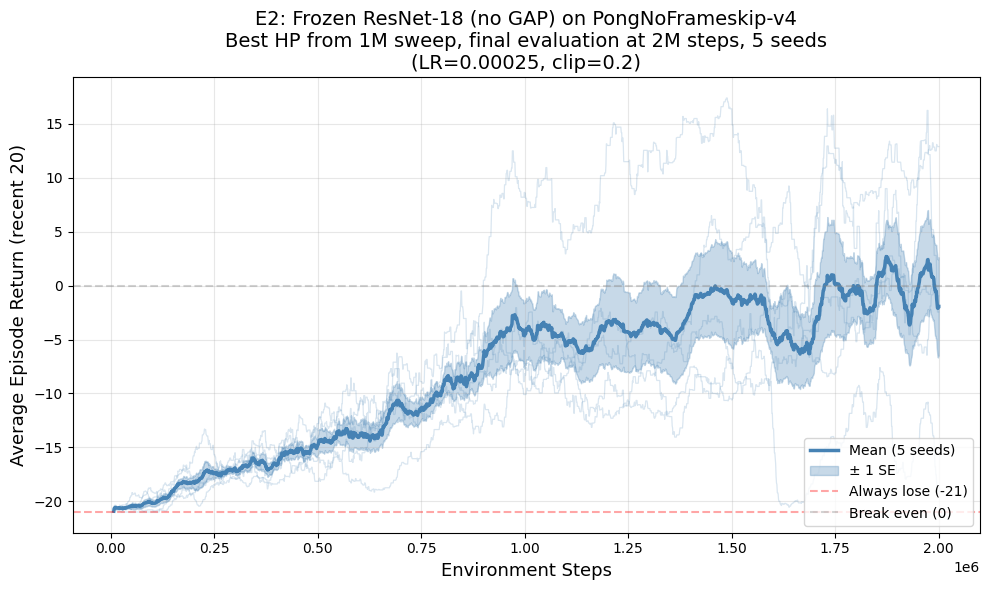

In [11]:
# ======================================================================
# CELL 11: Plot 1 — Reward Curve
# mean ± SE across 5 seeds, plus faint per-seed traces
# ======================================================================

def plot_return_curves(all_logs, title, save_path=None):
    fig, ax = plt.subplots(figsize=(10, 6))
    seeds = sorted(all_logs.keys())

    min_len = min(len(all_logs[s]) for s in seeds)
    if len({len(all_logs[s]) for s in seeds}) != 1:
        print("Warning: log lengths differ; truncating all runs to the shortest length.")

    for seed in seeds:
        df = all_logs[seed].iloc[:min_len]
        ax.plot(
            df["global_step"],
            df["recent_return_mean"],
            alpha=0.20,
            linewidth=0.9,
            color="steelblue",
        )

    ref = all_logs[seeds[0]].iloc[:min_len]["global_step"].values
    mat = np.array([all_logs[s].iloc[:min_len]["recent_return_mean"].values for s in seeds])

    mean_curve = np.nanmean(mat, axis=0)
    se_curve = np.nanstd(mat, axis=0) / np.sqrt(len(seeds))

    ax.plot(ref, mean_curve, linewidth=2.5, color="steelblue", label=f"Mean ({len(seeds)} seeds)")
    ax.fill_between(ref, mean_curve - se_curve, mean_curve + se_curve, alpha=0.30, color="steelblue", label="± 1 SE")
    ax.axhline(-21, color="red", linestyle="--", alpha=0.35, label="Always lose (-21)")
    ax.axhline(0, color="gray", linestyle="--", alpha=0.35, label="Break even (0)")

    ax.set_xlabel("Environment Steps", fontsize=13)
    ax.set_ylabel("Average Episode Return (recent 20)", fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=10, loc="lower right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved -> {save_path}")

    plt.show()

plot_return_curves(
    all_logs,
    (
        f"E2: Frozen ResNet-18 (no GAP) on {ENV_ID}\n"
        f"Best HP from 1M sweep, final evaluation at 2M steps, 5 seeds\n"
        f"(LR={BEST_LR}, clip={BEST_CLIP})"
    ),
    project_root / "outputs" / "plots" / "e2_return_curve.png",
)

In [12]:
# ======================================================================
# CELL 12: Sample Efficiency
# ======================================================================

def compute_sample_efficiency(all_logs, threshold_frac=0.70):
    seeds = sorted(all_logs.keys())
    min_return, max_return = -21.0, 21.0

    overall_best = max(all_logs[s]["recent_return_mean"].max() for s in seeds)
    norm_best = (overall_best - min_return) / (max_return - min_return)
    threshold = threshold_frac * norm_best * (max_return - min_return) + min_return

    print(f"Overall best mean return: {overall_best:.2f}")
    print(f"Threshold ({threshold_frac:.0%} of normalized best): {threshold:.2f}\n")

    results = {}
    for seed in seeds:
        df = all_logs[seed]
        reached = df[df["recent_return_mean"] >= threshold]
        if len(reached) > 0:
            step = int(reached.iloc[0]["global_step"])
            results[seed] = step
            print(f"Seed {seed}: reached {threshold:.2f} at step {step:,}")
        else:
            results[seed] = None
            print(f"Seed {seed}: never reached {threshold:.2f}")

    valid = [v for v in results.values() if v is not None]
    if valid:
        print(f"\nSample efficiency: {np.mean(valid):,.0f} ± {np.std(valid):,.0f} steps")
    else:
        print("\nNo seed reached the threshold.")

    return results

efficiency = compute_sample_efficiency(all_logs)

Overall best mean return: 17.40
Threshold (70% of normalized best): 5.88

Seed 0: reached 5.88 at step 1,447,000
Seed 1: reached 5.88 at step 919,000
Seed 2: never reached 5.88
Seed 3: never reached 5.88
Seed 4: never reached 5.88

Sample efficiency: 1,183,000 ± 264,000 steps


In [13]:
# ======================================================================
# CELL 13: Throughput Table
# ======================================================================

print(f"\n{'Seed':<10} {'SPS':>8} {'Wall (min)':>12} {'Best':>8} {'Final Mean':>12}")
print("-" * 58)

for seed in sorted(all_summaries.keys()):
    s = all_summaries[seed]
    print(
        f"{seed:<10} "
        f"{s['mean_sps']:>8.0f} "
        f"{s['wall_clock_sec']/60:>12.1f} "
        f"{s['best_episode_return']:>8.0f} "
        f"{s['final_recent_return_mean']:>12.2f}"
    )

spss = [s["mean_sps"] for s in all_summaries.values()]
print("-" * 58)
print(f"{'Mean':<10} {np.mean(spss):>8.0f} ± {np.std(spss):.0f}")


Seed            SPS   Wall (min)     Best   Final Mean
----------------------------------------------------------
0               375         88.3       20        12.90
1               381         87.5       21        -2.45
2               382         87.0       10       -19.10
3               384         86.6        8        -0.05
4               384         86.4       18        -0.95
----------------------------------------------------------
Mean            381 ± 4


Saved -> e2_hp_sweep.png


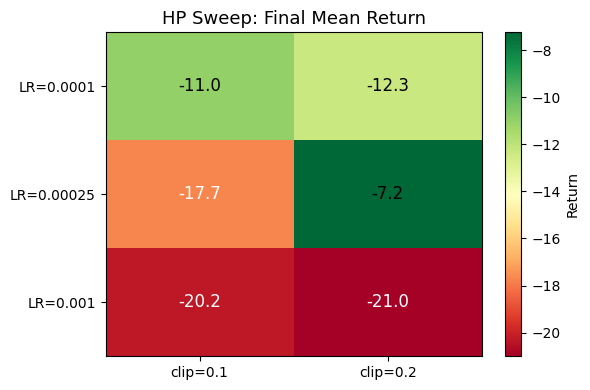

In [14]:
# ======================================================================
# CELL 14: Hyperparameter Sweep Heatmap
# ======================================================================

pivot = (
    sweep_df
    .pivot(index="lr", columns="clip_coef", values="final_mean")
    .sort_index()
    .sort_index(axis=1)
)

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"clip={c}" for c in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"LR={lr}" for lr in pivot.index])

pivot_mean = np.nanmean(pivot.values)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        value = pivot.values[i, j]
        ax.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center",
            fontsize=12,
            color="white" if value < pivot_mean else "black",
        )

ax.set_title("HP Sweep: Final Mean Return", fontsize=13)
plt.colorbar(im, ax=ax, label="Return")
plt.tight_layout()
plt.savefig(project_root / "outputs" / "plots" / "e2_hp_sweep.png", dpi=150, bbox_inches="tight")
print("Saved -> e2_hp_sweep.png")
plt.show()

In [15]:
# ======================================================================
# CELL 15: Load Best Final Model for Attribution and Probing
# ======================================================================

best_seed = max(all_summaries, key=lambda s: all_summaries[s]["best_episode_return"])
ckpt_path = project_root / "outputs" / "checkpoints" / f"E2_final_seed{best_seed}" / "best.pt"

agent = E2Agent(action_dim=action_dim).to(device)
agent.load_state_dict(load_checkpoint_state_dict(ckpt_path, device))
agent.eval()

print(f"Loaded best seed {best_seed} from {ckpt_path}")
print(f"best_return = {all_summaries[best_seed]['best_episode_return']}")

Loaded best seed 1 from E2_experiment_windows_gpu\outputs\checkpoints\E2_final_seed1\best.pt
best_return = 21.0


Saved -> e2_gradcam.png


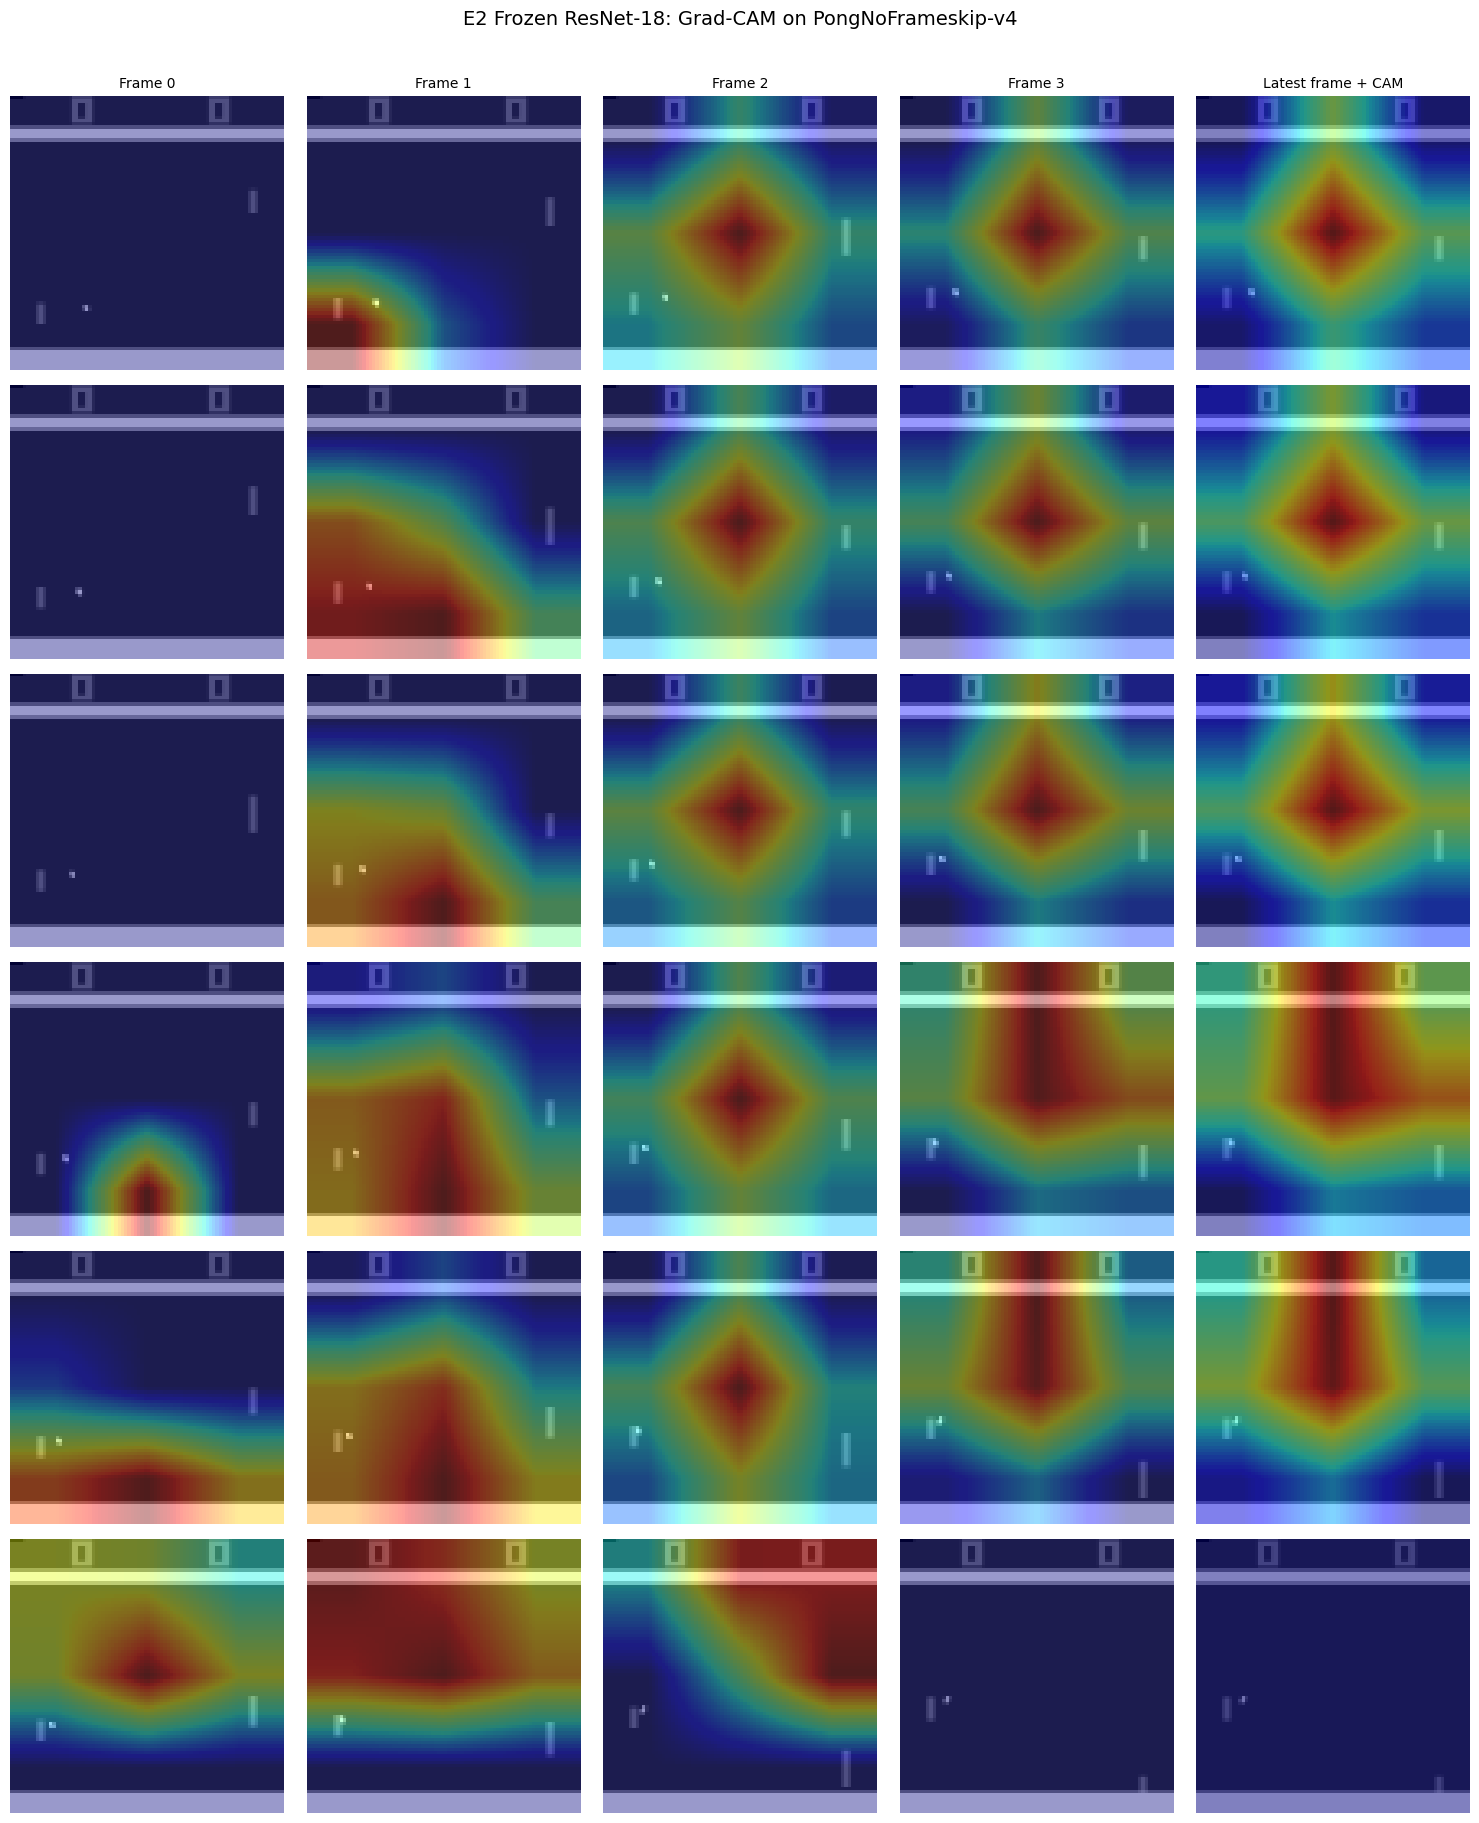

In [16]:
# ======================================================================
# CELL 16: Grad-CAM
# ======================================================================

class GradCAME2:
    def __init__(self, agent):
        self.agent = agent
        self.gradients = None
        self.activations = None

    def _hook(self, grad):
        self.gradients = grad

    def generate(self, obs_single, target_action=None):
        self.agent.eval()

        x = obs_single.float() / 255.0
        x = x.reshape(NUM_STACK, 1, 84, 84).repeat(1, 3, 1, 1)
        x = (x - self.agent.encoder.mean) / self.agent.encoder.std
        x.requires_grad_(True)

        features = self.agent.encoder.backbone(x)
        features.register_hook(self._hook)
        self.activations = features

        z = features.view(1, -1)
        h = self.agent.projection(z)
        h = self.agent.shared(h)
        logits = self.agent.actor(h)

        if target_action is None:
            target_action = logits.argmax(-1).item()

        self.agent.zero_grad()
        logits[0, target_action].backward()

        grads = self.gradients.detach()
        acts = self.activations.detach()

        weights = grads.mean(dim=[2, 3])
        cam = (weights[:, :, None, None] * acts).sum(dim=1)
        cam = F.relu(cam)
        cam = F.interpolate(cam.unsqueeze(1), size=(84, 84), mode="bilinear", align_corners=False).squeeze(1)

        for i in range(NUM_STACK):
            c = cam[i]
            if c.max() > c.min():
                cam[i] = (c - c.min()) / (c.max() - c.min())
            else:
                cam[i] = torch.zeros_like(c)

        return cam.cpu().numpy(), target_action


gradcam = GradCAME2(agent)
viz_env = make_env(0, 0)()
obs, _ = viz_env.reset(seed=0)

for _ in range(80):
    obs, _, terminated, truncated, _ = viz_env.step(viz_env.action_space.sample())
    if terminated or truncated:
        obs, _ = viz_env.reset()

action_meanings = viz_env.unwrapped.get_action_meanings()
NUM_ROWS = 6

fig, axes = plt.subplots(NUM_ROWS, 5, figsize=(15, 3 * NUM_ROWS))

for row in range(NUM_ROWS):
    obs_t = torch.as_tensor(np.asarray(obs), dtype=torch.uint8, device=device).unsqueeze(0)
    cam_maps, act = gradcam.generate(obs_t)

    for col in range(NUM_STACK):
        axes[row, col].imshow(np.asarray(obs)[col], cmap="gray")
        axes[row, col].imshow(cam_maps[col], cmap="jet", alpha=0.4)
        if row == 0:
            axes[row, col].set_title(f"Frame {col}", fontsize=10)
        axes[row, col].axis("off")

    axes[row, 4].imshow(np.asarray(obs)[-1], cmap="gray")
    axes[row, 4].imshow(cam_maps[-1], cmap="jet", alpha=0.5)
    if row == 0:
        axes[row, 4].set_title("Latest frame + CAM", fontsize=10)
    axes[row, 4].axis("off")
    axes[row, 0].set_ylabel(f"{action_meanings[act]}", fontsize=9, rotation=0, labelpad=50)

    with torch.no_grad():
        a_t, _, _, _ = agent.get_action_and_value(obs_t)

    obs, _, terminated, truncated, _ = viz_env.step(a_t.cpu().item())
    if terminated or truncated:
        obs, _ = viz_env.reset()

plt.suptitle(f"E2 Frozen ResNet-18: Grad-CAM on {ENV_ID}", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(project_root / "outputs" / "plots" / "e2_gradcam.png", dpi=150, bbox_inches="tight")
print("Saved -> e2_gradcam.png")
plt.show()

viz_env.close()

Using run: E2_final_seed0
Checkpoint dir: E2_experiment_windows_gpu\outputs\checkpoints\E2_final_seed0
Log path: E2_experiment_windows_gpu\outputs\logs\E2_final_seed0\train_log.csv

Available snapshots:
    ckpt_500 | step=500,000 | ckpt_500.pt
   ckpt_1000 | step=1,000,000 | ckpt_1000.pt
   ckpt_1500 | step=1,500,000 | ckpt_1500.pt
   ckpt_2000 | step=2,000,000 | ckpt_2000.pt
       final | step=2,000,000 | final.pt

Selected snapshots:
  target=500,000 -> ckpt_500 (actual=500,000, update=500)
  target=1,000,000 -> ckpt_1000 (actual=1,000,000, update=1000)
  target=2,000,000 -> ckpt_2000 (actual=2,000,000, update=2000)


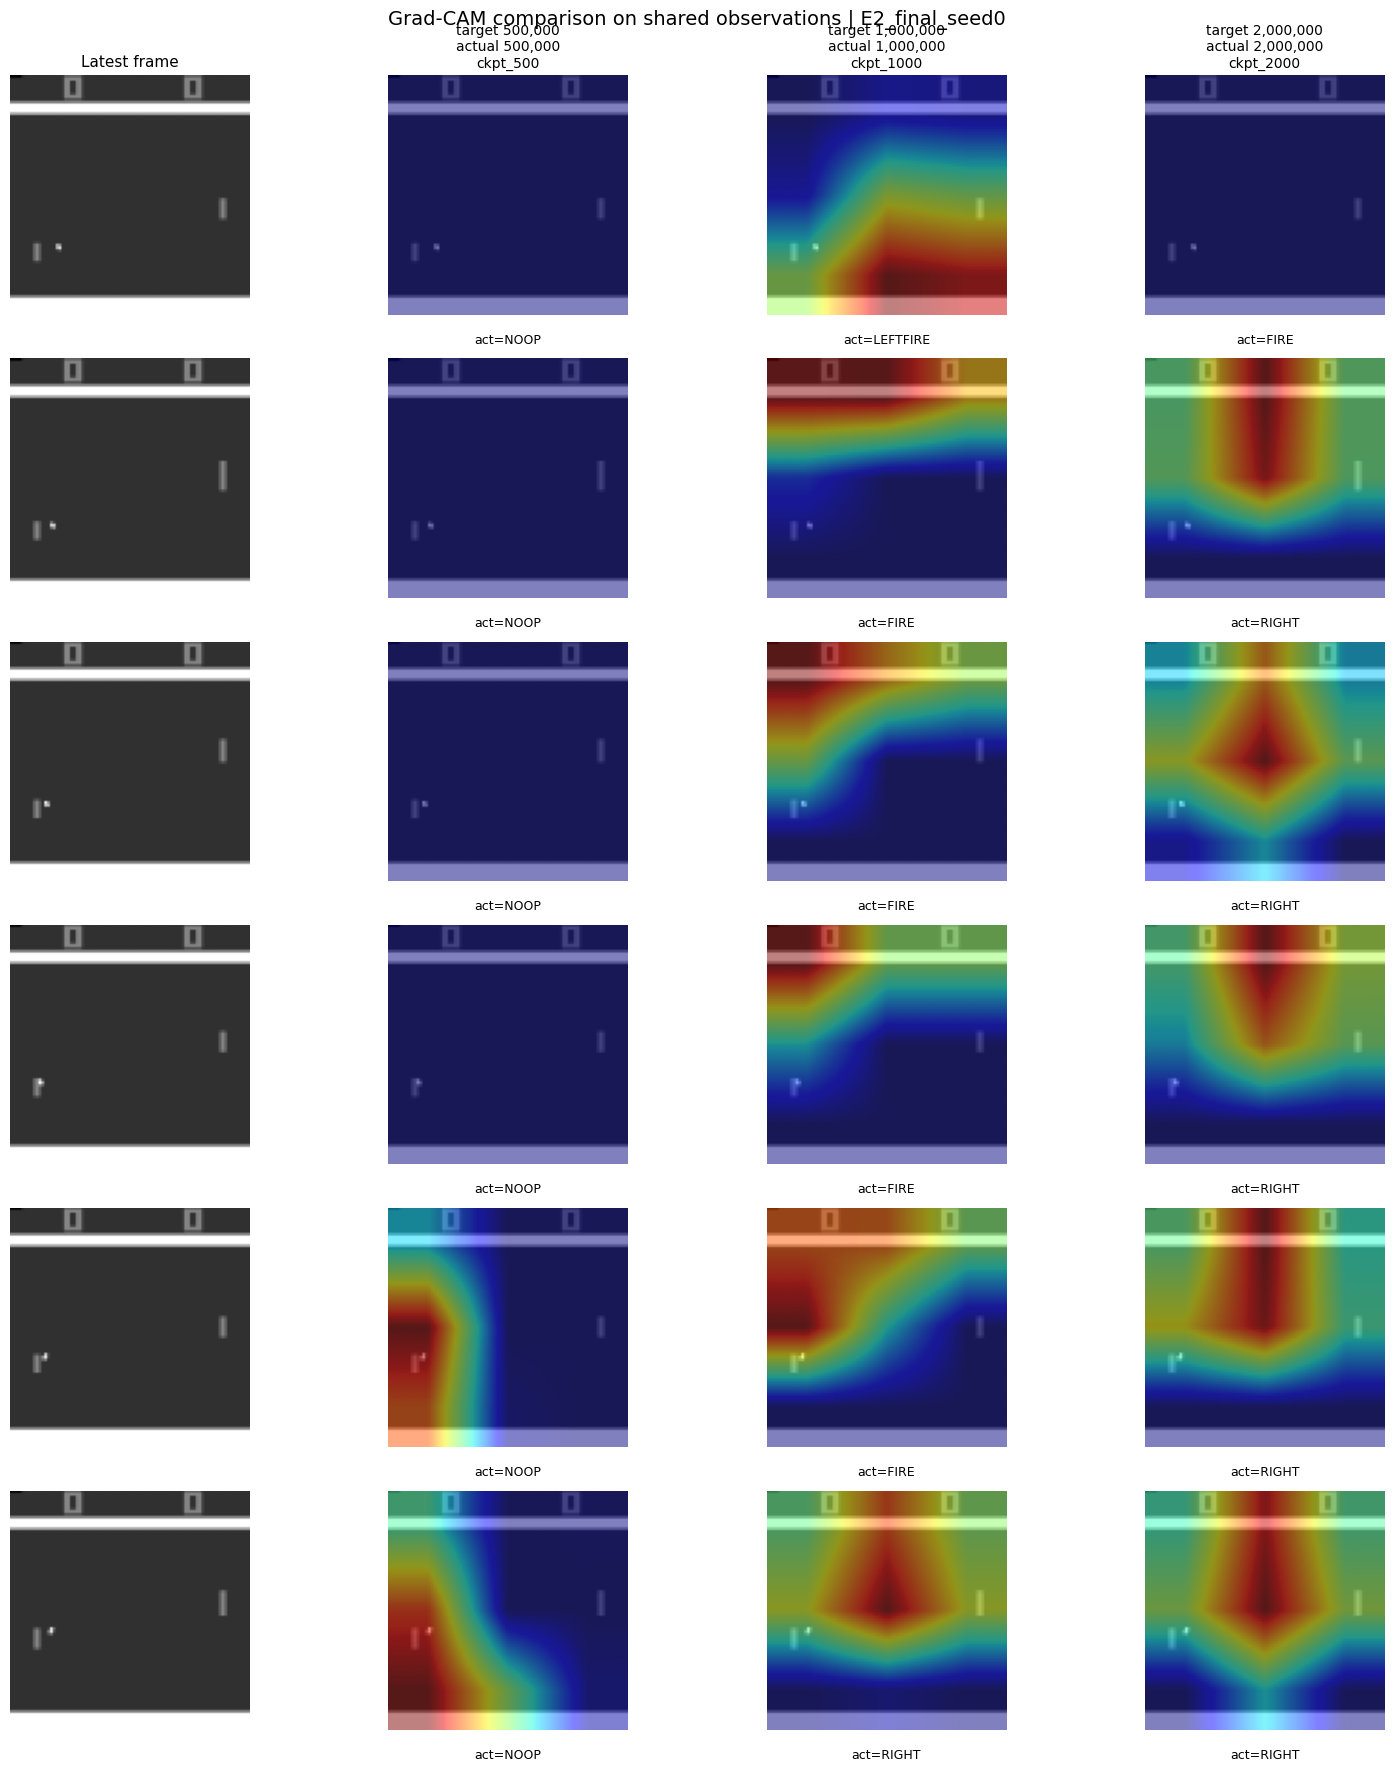


Saved -> E2_experiment_windows_gpu\outputs\plots\e2_gradcam_compare_E2_final_seed0.png


In [6]:
# ======================================================================
# CELL X: Compare Grad-CAM across training stages (nearest checkpoints)
# ======================================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# -----------------------------
# 1) Config
# -----------------------------
COMPARE_TARGET_STEPS = [500_000, 1_000_000, 2_000_000]
NUM_ROWS = 6            # number of shared observations to visualize
BURN_IN_RANDOM = 80     # random steps before collecting observations
TRAJ_SEED = 0           # seed for shared observation trajectory

# Choose which seed to analyze.
# Option A: use the best seed already computed in previous cells
run_seed = best_seed if "best_seed" in globals() else 0

# If you want to force a specific seed, uncomment:
# run_seed = 0

run_name = f"E2_final_seed{run_seed}"
ckpt_dir = project_root / "outputs" / "checkpoints" / run_name
log_path = project_root / "outputs" / "logs" / run_name / "train_log.csv"

print(f"Using run: {run_name}")
print(f"Checkpoint dir: {ckpt_dir}")
print(f"Log path: {log_path}")

assert ckpt_dir.exists(), f"Checkpoint directory not found: {ckpt_dir}"
assert log_path.exists(), f"Train log not found: {log_path}"

# -----------------------------
# 2) Standalone Grad-CAM helper
# -----------------------------
class GradCAME2Compare:
    def __init__(self, agent):
        self.agent = agent
        self.gradients = None
        self.activations = None

    def _hook(self, grad):
        self.gradients = grad

    def generate(self, obs_single, target_action=None):
        """
        obs_single: (1, 4, 84, 84) uint8
        returns:
            cam_maps: (4, 84, 84)
            target_action: int
        """
        self.agent.eval()

        x = obs_single.float() / 255.0
        x = x.reshape(4, 1, 84, 84).repeat(1, 3, 1, 1)
        x = (x - self.agent.encoder.mean) / self.agent.encoder.std
        x.requires_grad_(True)

        features = self.agent.encoder.backbone(x)
        features.register_hook(self._hook)
        self.activations = features

        z = features.view(1, -1)
        h = self.agent.projection(z)
        h = self.agent.shared(h)
        logits = self.agent.actor(h)

        if target_action is None:
            target_action = logits.argmax(-1).item()

        self.agent.zero_grad()
        logits[0, target_action].backward()

        grads = self.gradients.detach()      # (4, C, H, W)
        acts = self.activations.detach()     # (4, C, H, W)

        weights = grads.mean(dim=[2, 3])     # (4, C)
        cam = (weights[:, :, None, None] * acts).sum(dim=1)   # (4, H, W)
        cam = F.relu(cam)
        cam = F.interpolate(
            cam.unsqueeze(1), size=(84, 84), mode="bilinear", align_corners=False
        ).squeeze(1)

        for i in range(4):
            c = cam[i]
            if c.max() > c.min():
                cam[i] = (c - c.min()) / (c.max() - c.min())
            else:
                cam[i] = torch.zeros_like(c)

        return cam.cpu().numpy(), target_action


# -----------------------------
# 3) Helper: load state dict safely
# -----------------------------
def load_state_dict_safely(path, device):
    obj = torch.load(path, map_location=device)
    if isinstance(obj, dict):
        if "state_dict" in obj:
            return obj["state_dict"]
        return obj
    raise ValueError(f"Unsupported checkpoint format: {path}")


# -----------------------------
# 4) Build available snapshot table from ckpt_*.pt + final.pt
# -----------------------------
log_df = pd.read_csv(log_path)

# expected columns: update, global_step, ...
assert "update" in log_df.columns and "global_step" in log_df.columns

available = []

# Parse ckpt_*.pt
for p in ckpt_dir.glob("ckpt_*.pt"):
    m = re.match(r"ckpt_(\d+)\.pt", p.name)
    if not m:
        continue
    upd = int(m.group(1))
    hit = log_df.loc[log_df["update"] == upd]
    if len(hit) == 0:
        continue
    step = int(hit.iloc[0]["global_step"])
    available.append({
        "label": f"ckpt_{upd}",
        "path": p,
        "update": upd,
        "global_step": step,
        "kind": "periodic"
    })

# Add final.pt
final_pt = ckpt_dir / "final.pt"
if final_pt.exists():
    last_row = log_df.iloc[-1]
    available.append({
        "label": "final",
        "path": final_pt,
        "update": int(last_row["update"]),
        "global_step": int(last_row["global_step"]),
        "kind": "final"
    })

# Sort
available = sorted(available, key=lambda x: x["global_step"])
assert len(available) > 0, f"No periodic/final checkpoints found in {ckpt_dir}"

print("\nAvailable snapshots:")
for item in available:
    print(f"  {item['label']:>10s} | step={item['global_step']:,} | {item['path'].name}")

# Match each target step to nearest available snapshot
selected = []
used_paths = set()

for target in COMPARE_TARGET_STEPS:
    best_item = min(available, key=lambda x: abs(x["global_step"] - target))
    selected.append({
        "target_step": target,
        "actual_step": best_item["global_step"],
        "update": best_item["update"],
        "label": best_item["label"],
        "path": best_item["path"],
    })

print("\nSelected snapshots:")
for s in selected:
    print(
        f"  target={s['target_step']:,} -> "
        f"{s['label']} (actual={s['actual_step']:,}, update={s['update']})"
    )

# -----------------------------
# 5) Collect shared observations
#    Important: same observations for all checkpoints
# -----------------------------
viz_env = make_env(TRAJ_SEED, 0)()
obs, _ = viz_env.reset(seed=TRAJ_SEED)

rng = np.random.default_rng(TRAJ_SEED)

# burn-in with fixed random actions
for _ in range(BURN_IN_RANDOM):
    a = int(rng.integers(viz_env.action_space.n))
    obs, _, terminated, truncated, _ = viz_env.step(a)
    if terminated or truncated:
        obs, _ = viz_env.reset(seed=TRAJ_SEED)

shared_obs = []
for _ in range(NUM_ROWS):
    shared_obs.append(np.asarray(obs).copy())
    a = int(rng.integers(viz_env.action_space.n))
    obs, _, terminated, truncated, _ = viz_env.step(a)
    if terminated or truncated:
        obs, _ = viz_env.reset(seed=TRAJ_SEED)

action_meanings = viz_env.unwrapped.get_action_meanings()

# -----------------------------
# 6) Run Grad-CAM for each selected checkpoint on the same observations
# -----------------------------
results = []

for s in selected:
    ckpt_path = s["path"]

    agent_cmp = E2Agent(action_dim=action_dim).to(device)
    agent_cmp.load_state_dict(load_state_dict_safely(ckpt_path, device))
    agent_cmp.eval()

    gradcam_cmp = GradCAME2Compare(agent_cmp)

    cam_list = []
    act_list = []

    for obs_np in shared_obs:
        obs_t = torch.as_tensor(obs_np, dtype=torch.uint8, device=device).unsqueeze(0)
        cam_maps, act = gradcam_cmp.generate(obs_t)
        cam_list.append(cam_maps)
        act_list.append(act)

    results.append({
        "meta": s,
        "cams": cam_list,
        "actions": act_list,
    })

# -----------------------------
# 7) Plot: first col = raw frame, next cols = 500k / 1M / 2M
# -----------------------------
ncols = 1 + len(results)
fig, axes = plt.subplots(NUM_ROWS, ncols, figsize=(4 * ncols, 3 * NUM_ROWS))

if NUM_ROWS == 1:
    axes = np.expand_dims(axes, axis=0)

# headers
axes[0, 0].set_title("Latest frame", fontsize=11)
for j, r in enumerate(results, start=1):
    meta = r["meta"]
    axes[0, j].set_title(
        f"target {meta['target_step']:,}\nactual {meta['actual_step']:,}\n{meta['label']}",
        fontsize=10
    )

for i in range(NUM_ROWS):
    obs_np = shared_obs[i]
    latest_frame = obs_np[-1]

    # raw image
    axes[i, 0].imshow(latest_frame, cmap="gray")
    axes[i, 0].axis("off")
    axes[i, 0].set_ylabel(f"Obs {i}", fontsize=10)

    # cams from different checkpoints
    for j, r in enumerate(results, start=1):
        cam_latest = r["cams"][i][-1]
        act = r["actions"][i]

        axes[i, j].imshow(latest_frame, cmap="gray")
        axes[i, j].imshow(cam_latest, cmap="jet", alpha=0.5)
        axes[i, j].axis("off")
        axes[i, j].text(
            0.5, -0.08,
            f"act={action_meanings[act]}",
            transform=axes[i, j].transAxes,
            ha="center", va="top", fontsize=9
        )

plt.suptitle(f"Grad-CAM comparison on shared observations | {run_name}", fontsize=14)
plt.tight_layout()

save_path = project_root / "outputs" / "plots" / f"e2_gradcam_compare_{run_name}.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSaved -> {save_path}")

Saved -> e2_integrated_gradients.png


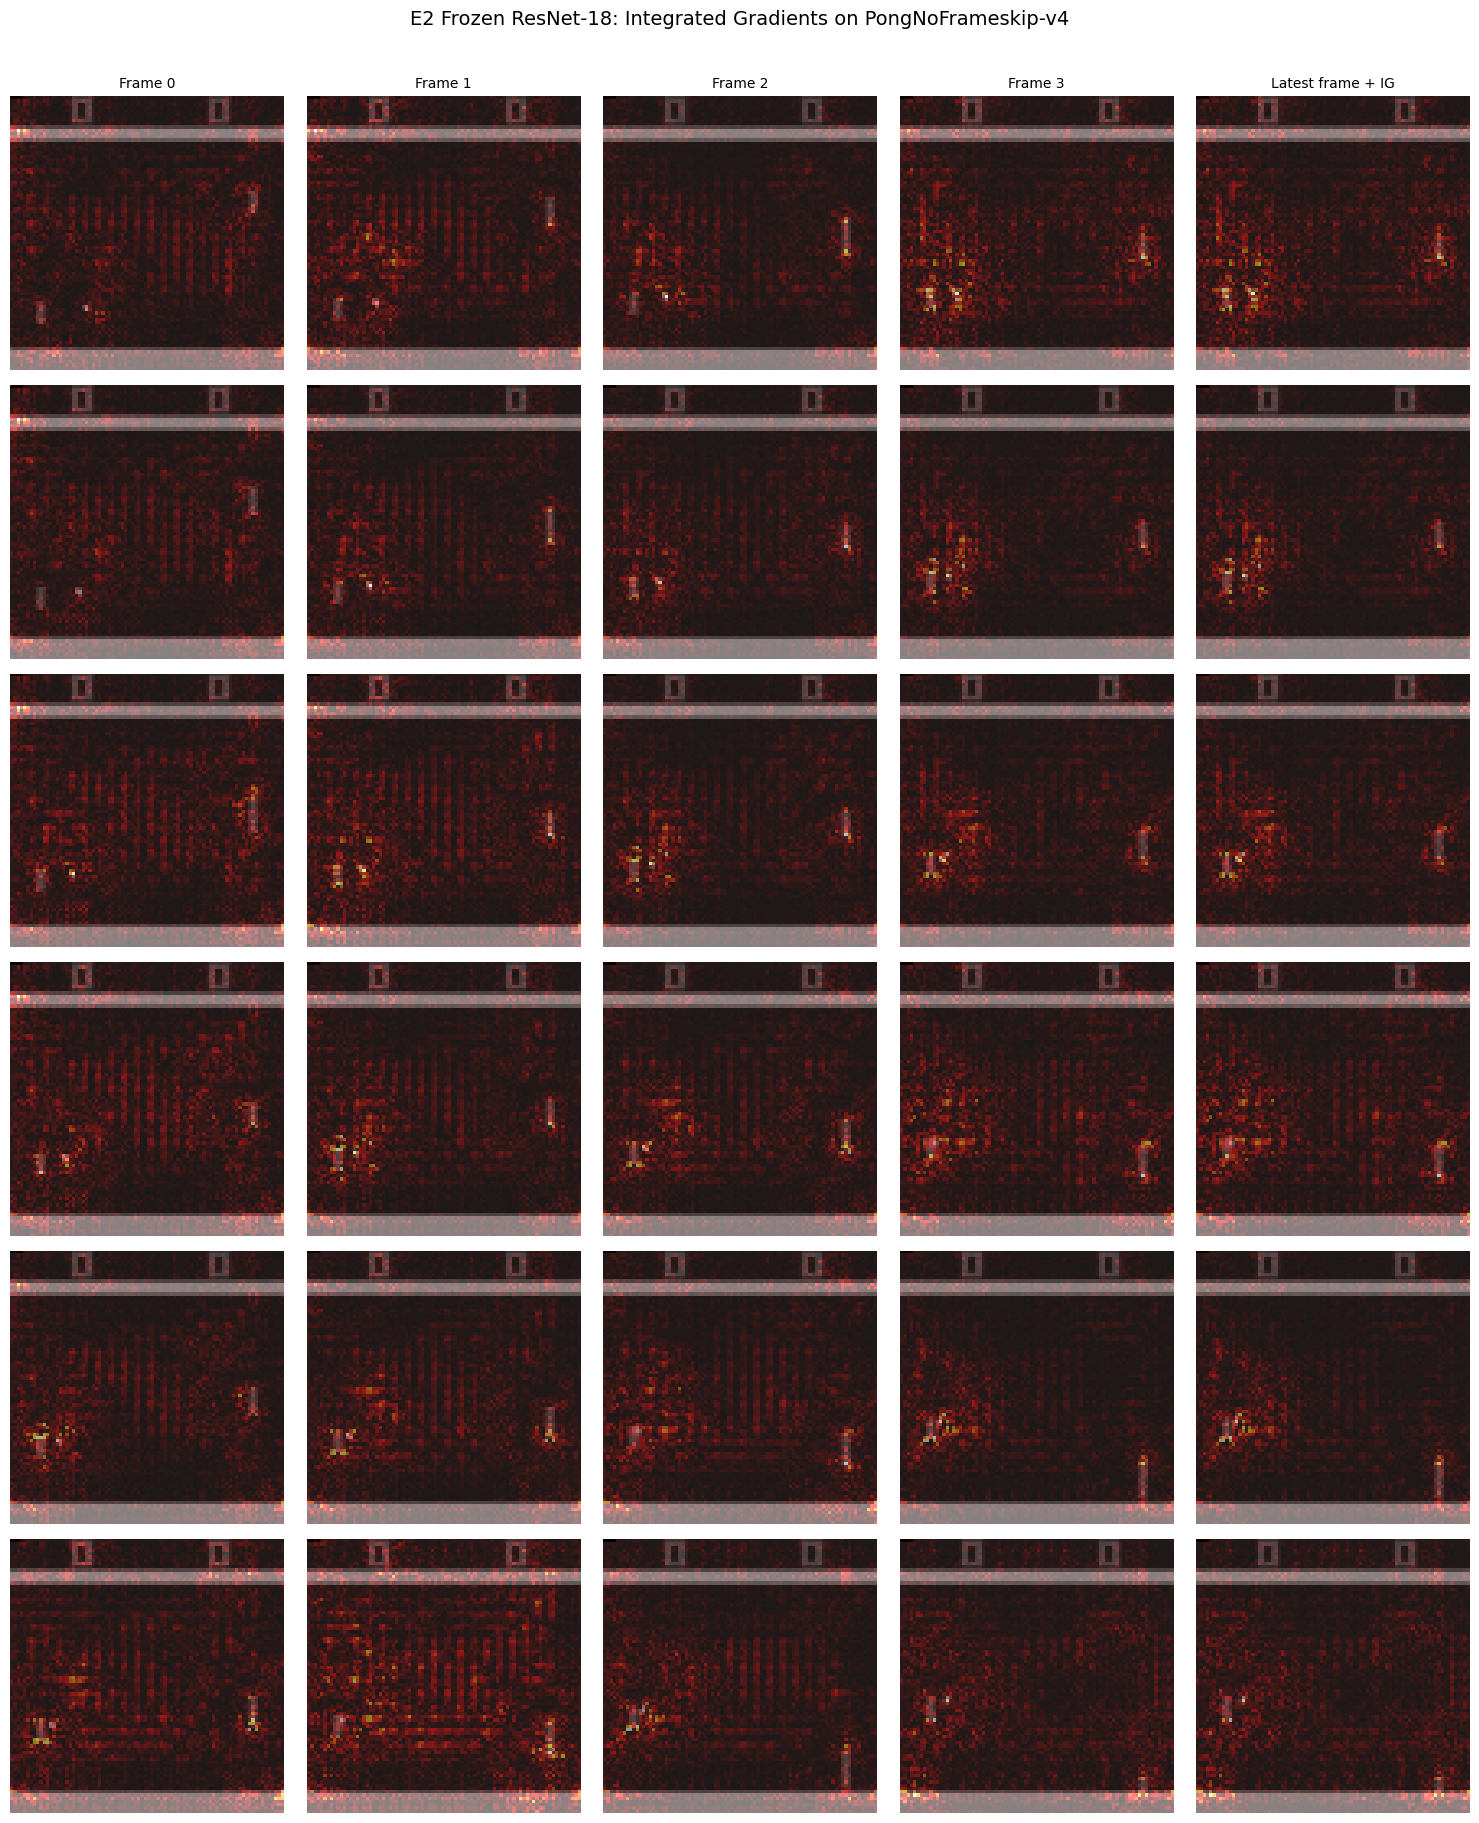

In [17]:
# ======================================================================
# CELL 17: Integrated Gradients
# ======================================================================

class IntegratedGradientsE2:
    def __init__(self, agent, n_steps=50):
        self.agent = agent
        self.n_steps = n_steps

    def generate(self, obs_single, target_action=None):
        self.agent.eval()

        baseline = torch.zeros_like(obs_single, dtype=torch.float32)
        inp = obs_single.float()

        if target_action is None:
            with torch.no_grad():
                h = self.agent.forward_features(obs_single)
                target_action = self.agent.actor(h).argmax(-1).item()

        all_grads = []
        for k in range(self.n_steps + 1):
            alpha = k / self.n_steps
            scaled = (baseline + alpha * (inp - baseline)).clone().requires_grad_(True)

            x = scaled / 255.0
            x = x.reshape(NUM_STACK, 1, 84, 84).repeat(1, 3, 1, 1)
            x = (x - self.agent.encoder.mean) / self.agent.encoder.std

            feat = self.agent.encoder.backbone(x)
            z = feat.view(1, -1)
            h = self.agent.projection(z)
            h = self.agent.shared(h)
            logits = self.agent.actor(h)

            self.agent.zero_grad()
            logits[0, target_action].backward()
            all_grads.append(scaled.grad.detach().clone())

        avg_grad = torch.stack(all_grads).mean(0)
        attr = ((inp - baseline) * avg_grad).squeeze(0).abs()

        for i in range(NUM_STACK):
            a = attr[i]
            if a.max() > a.min():
                attr[i] = (a - a.min()) / (a.max() - a.min())
            else:
                attr[i] = torch.zeros_like(a)

        return attr.cpu().numpy(), target_action


ig = IntegratedGradientsE2(agent, n_steps=50)
viz_env = make_env(0, 0)()
obs, _ = viz_env.reset(seed=0)

for _ in range(80):
    obs, _, terminated, truncated, _ = viz_env.step(viz_env.action_space.sample())
    if terminated or truncated:
        obs, _ = viz_env.reset()

fig, axes = plt.subplots(NUM_ROWS, 5, figsize=(15, 3 * NUM_ROWS))

for row in range(NUM_ROWS):
    obs_t = torch.as_tensor(np.asarray(obs), dtype=torch.uint8, device=device).unsqueeze(0)
    attr_maps, act = ig.generate(obs_t)

    for col in range(NUM_STACK):
        axes[row, col].imshow(np.asarray(obs)[col], cmap="gray")
        axes[row, col].imshow(attr_maps[col], cmap="hot", alpha=0.5)
        if row == 0:
            axes[row, col].set_title(f"Frame {col}", fontsize=10)
        axes[row, col].axis("off")

    axes[row, 4].imshow(np.asarray(obs)[-1], cmap="gray")
    axes[row, 4].imshow(attr_maps[-1], cmap="hot", alpha=0.5)
    if row == 0:
        axes[row, 4].set_title("Latest frame + IG", fontsize=10)
    axes[row, 4].axis("off")
    axes[row, 0].set_ylabel(f"{action_meanings[act]}", fontsize=9, rotation=0, labelpad=50)

    with torch.no_grad():
        a_t, _, _, _ = agent.get_action_and_value(obs_t)

    obs, _, terminated, truncated, _ = viz_env.step(a_t.cpu().item())
    if terminated or truncated:
        obs, _ = viz_env.reset()

plt.suptitle(f"E2 Frozen ResNet-18: Integrated Gradients on {ENV_ID}", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(project_root / "outputs" / "plots" / "e2_integrated_gradients.png", dpi=150, bbox_inches="tight")
print("Saved -> e2_integrated_gradients.png")
plt.show()

viz_env.close()

  1000/5000
  2000/5000
  3000/5000
  4000/5000
  5000/5000
Dataset: (5000, 4, 84, 84)
Random baseline: 22.49 px

Extracting features...
Spatial: (5000, 18432)
Policy:  (5000, 512)

Linear Probe: Spatial vs Policy Features
  [Spatial] Epoch 25: 17.16 px
  [Spatial] Epoch 50: 14.42 px
  [Spatial] Epoch 75: 13.05 px
  [Spatial] Epoch 100: 11.56 px
  [Spatial] Final: 11.56 px
  [Policy] Epoch 25: 67.33 px
  [Policy] Epoch 50: 62.31 px
  [Policy] Epoch 75: 57.57 px
  [Policy] Epoch 100: 53.13 px
  [Policy] Final: 53.13 px

Feature                    Dims      Error    vs Random
--------------------------------------------------------
Random baseline               -      22.49            -
Spatial (backbone)        18432      11.56        48.6%
Policy (head)               512      53.13      -136.2%
Saved -> e2_linear_probe.png


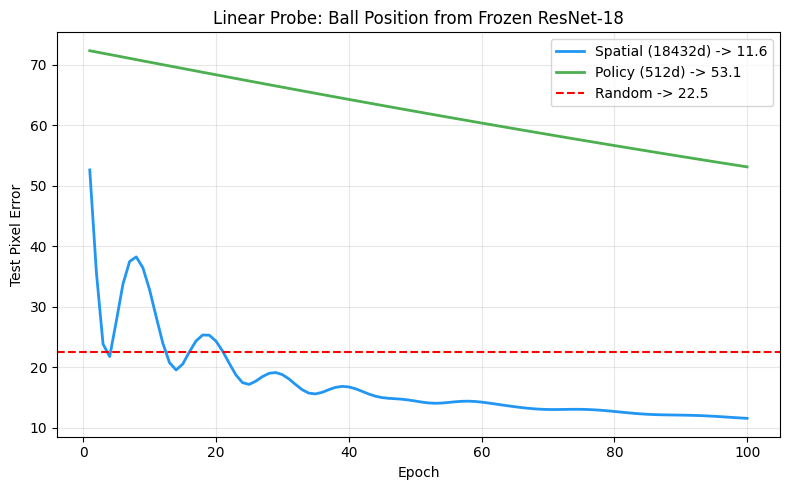

Saved -> e2_linear_probe_bar.png


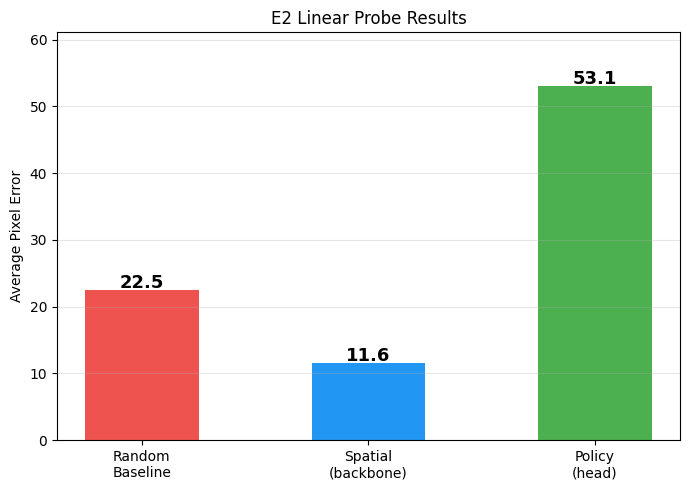

Saved probe features for later CKA or report usage.


In [18]:
# ======================================================================
# CELL 18: Linear Probe — Ball Position Prediction
# Compare backbone spatial features (18432d) vs policy features (512d)
# ======================================================================

from scipy import ndimage
from sklearn.model_selection import train_test_split

def find_ball_position(frame):
    binary = (frame > 200).astype(np.uint8)
    labeled, n = ndimage.label(binary)
    if n == 0:
        return None

    best_pos, best_size = None, 999
    for lid in range(1, n + 1):
        ys, xs = np.where(labeled == lid)
        size = len(ys)
        if 1 <= size <= 10 and size < best_size:
            best_size = size
            best_pos = (float(ys.mean()), float(xs.mean()))
    return best_pos


print("Collecting probing dataset...")
probe_env = make_env(0, 0)()
observations, positions = [], []

obs_p, _ = probe_env.reset(seed=0)
collected = 0

while collected < 5000:
    obs_p, _, terminated, truncated, _ = probe_env.step(probe_env.action_space.sample())
    if terminated or truncated:
        obs_p, _ = probe_env.reset()
        continue

    pos = find_ball_position(np.asarray(obs_p)[-1])
    if pos is not None:
        observations.append(np.asarray(obs_p))
        positions.append(pos)
        collected += 1
        if collected % 1000 == 0:
            print(f"  {collected}/5000")

probe_env.close()

obs_data = np.asarray(observations, dtype=np.uint8)
ball_data = np.asarray(positions, dtype=np.float32)

print("Dataset:", obs_data.shape)

mean_pos = ball_data.mean(axis=0)
random_baseline = np.sqrt(((ball_data - mean_pos) ** 2).sum(axis=1)).mean()
print(f"Random baseline: {random_baseline:.2f} px")

print("\nExtracting features...")
agent.eval()

feats_spatial = []
with torch.no_grad():
    for i in range(0, len(obs_data), 64):
        batch = torch.as_tensor(obs_data[i:i+64], dtype=torch.uint8, device=device)
        B = batch.shape[0]
        x = batch.float() / 255.0
        x = x.reshape(B * NUM_STACK, 1, 84, 84).repeat(1, 3, 1, 1)
        x = (x - agent.encoder.mean) / agent.encoder.std
        z = agent.encoder.backbone(x)
        feats_spatial.append(z.view(B, -1).cpu())

feats_spatial = torch.cat(feats_spatial).numpy()

feats_policy = []
with torch.no_grad():
    for i in range(0, len(obs_data), 128):
        batch = torch.as_tensor(obs_data[i:i+128], dtype=torch.uint8, device=device)
        feats_policy.append(agent.forward_features(batch).cpu())

feats_policy = torch.cat(feats_policy).numpy()

print("Spatial:", feats_spatial.shape)
print("Policy: ", feats_policy.shape)

def train_probe(features, targets, name, epochs=100, lr=1e-3):
    X_tr, X_te, y_tr, y_te = train_test_split(features, targets, test_size=0.2, random_state=42)

    X_tr = torch.as_tensor(X_tr, dtype=torch.float32)
    X_te = torch.as_tensor(X_te, dtype=torch.float32)
    y_tr = torch.as_tensor(y_tr, dtype=torch.float32)
    y_te = torch.as_tensor(y_te, dtype=torch.float32)

    probe = nn.Linear(features.shape[1], 2)
    opt = torch.optim.Adam(probe.parameters(), lr=lr)

    test_errs = []
    for epoch in range(epochs):
        probe.train()
        loss = F.mse_loss(probe(X_tr), y_tr)
        opt.zero_grad()
        loss.backward()
        opt.step()

        probe.eval()
        with torch.no_grad():
            err = torch.sqrt(((probe(X_te) - y_te) ** 2).sum(1)).mean().item()

        test_errs.append(err)
        if (epoch + 1) % 25 == 0:
            print(f"  [{name}] Epoch {epoch + 1}: {err:.2f} px")

    print(f"  [{name}] Final: {test_errs[-1]:.2f} px")
    return test_errs[-1], test_errs


print(f"\n{'='*68}\nLinear Probe: Spatial vs Policy Features\n{'='*68}")
err_sp, curve_sp = train_probe(feats_spatial, ball_data, "Spatial")
err_po, curve_po = train_probe(feats_policy, ball_data, "Policy")

print(f"\n{'='*68}")
print(f"{'Feature':<22} {'Dims':>8} {'Error':>10} {'vs Random':>12}")
print(f"{'-'*56}")
print(f"{'Random baseline':<22} {'-':>8} {random_baseline:>10.2f} {'-':>12}")
print(f"{'Spatial (backbone)':<22} {feats_spatial.shape[1]:>8} {err_sp:>10.2f} {(1 - err_sp / random_baseline) * 100:>11.1f}%")
print(f"{'Policy (head)':<22} {feats_policy.shape[1]:>8} {err_po:>10.2f} {(1 - err_po / random_baseline) * 100:>11.1f}%")
print(f"{'='*68}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(curve_sp) + 1), curve_sp, lw=2, color="#2196F3", label=f"Spatial ({feats_spatial.shape[1]}d) -> {err_sp:.1f}")
ax.plot(range(1, len(curve_po) + 1), curve_po, lw=2, color="#4CAF50", label=f"Policy ({feats_policy.shape[1]}d) -> {err_po:.1f}")
ax.axhline(random_baseline, color="red", linestyle="--", lw=1.5, label=f"Random -> {random_baseline:.1f}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test Pixel Error")
ax.set_title("Linear Probe: Ball Position from Frozen ResNet-18")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(project_root / "outputs" / "plots" / "e2_linear_probe.png", dpi=150, bbox_inches="tight")
print("Saved -> e2_linear_probe.png")
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
names = ["Random\nBaseline", "Spatial\n(backbone)", "Policy\n(head)"]
vals = [random_baseline, err_sp, err_po]
colors = ["#EF5350", "#2196F3", "#4CAF50"]
bars = ax.bar(names, vals, color=colors, width=0.5)

for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3, f"{v:.1f}", ha="center", fontsize=13, fontweight="bold")

ax.set_ylabel("Average Pixel Error")
ax.set_title("E2 Linear Probe Results")
ax.set_ylim(0, max(vals) * 1.15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(project_root / "outputs" / "plots" / "e2_linear_probe_bar.png", dpi=150, bbox_inches="tight")
print("Saved -> e2_linear_probe_bar.png")
plt.show()

probe_results = {
    "random_baseline": float(random_baseline),
    "spatial": {"dims": int(feats_spatial.shape[1]), "error": float(err_sp)},
    "policy": {"dims": int(feats_policy.shape[1]), "error": float(err_po)},
}

with open(project_root / "outputs" / "tables" / "linear_probe_results.json", "w") as f:
    json.dump(probe_results, f, indent=2)

np.save(project_root / "outputs" / "tables" / "shared_obs_data.npy", obs_data)
np.save(project_root / "outputs" / "tables" / "e2_features_spatial.npy", feats_spatial)
np.save(project_root / "outputs" / "tables" / "e2_features_policy.npy", feats_policy)

print("Saved probe features for later CKA or report usage.")

In [19]:
# ======================================================================
# CELL 19: CKA Similarity Helper (optional, requires E1 features)
# ======================================================================

def linear_CKA(X, Y):
    X = X - X.mean(axis=0)
    Y = Y - Y.mean(axis=0)

    hsic_xy = np.linalg.norm(X.T @ Y, ord="fro") ** 2
    hsic_xx = np.linalg.norm(X.T @ X, ord="fro") ** 2
    hsic_yy = np.linalg.norm(Y.T @ Y, ord="fro") ** 2

    return hsic_xy / (np.sqrt(hsic_xx * hsic_yy) + 1e-10)

print("CKA helper is ready. Load E1 features separately if needed.")

CKA helper is ready. Load E1 features separately if needed.


In [20]:
# ======================================================================
# CELL 20: Deliverables Check
# ======================================================================

print("=" * 68)
print("E2 Experiment — Deliverables Check")
print("=" * 68)

files = [
    ("HP Sweep Table", "outputs/tables/hp_sweep.csv"),
    ("5-Seed Summary", "outputs/tables/final_summaries.json"),
    ("Linear Probe Results", "outputs/tables/linear_probe_results.json"),
    ("Baselines", "outputs/tables/baselines.json"),
    ("Return Curve", "outputs/plots/e2_return_curve.png"),
    ("HP Sweep Heatmap", "outputs/plots/e2_hp_sweep.png"),
    ("Grad-CAM", "outputs/plots/e2_gradcam.png"),
    ("Integrated Gradients", "outputs/plots/e2_integrated_gradients.png"),
    ("Linear Probe Curves", "outputs/plots/e2_linear_probe.png"),
    ("Linear Probe Bar", "outputs/plots/e2_linear_probe_bar.png"),
    ("Shared Obs (CKA)", "outputs/tables/shared_obs_data.npy"),
    ("E2 Features Spatial", "outputs/tables/e2_features_spatial.npy"),
    ("E2 Features Policy", "outputs/tables/e2_features_policy.npy"),
]

for name, rel_path in files:
    ok = "OK" if (project_root / rel_path).exists() else "MISSING"
    print(f"{ok:<8} {name:<24} {rel_path}")

print()
for seed in FINAL_SEEDS:
    log_ok = (project_root / "outputs" / "logs" / f"E2_final_seed{seed}" / "train_log.csv").exists()
    ckpt_ok = (project_root / "outputs" / "checkpoints" / f"E2_final_seed{seed}" / "best.pt").exists()
    print(f"Seed {seed}: log={'OK' if log_ok else 'MISSING'} | ckpt={'OK' if ckpt_ok else 'MISSING'}")

print(f"\nProject root: {project_root.resolve()}")

E2 Experiment — Deliverables Check
OK       HP Sweep Table           outputs/tables/hp_sweep.csv
OK       5-Seed Summary           outputs/tables/final_summaries.json
OK       Linear Probe Results     outputs/tables/linear_probe_results.json
MISSING  Baselines                outputs/tables/baselines.json
OK       Return Curve             outputs/plots/e2_return_curve.png
OK       HP Sweep Heatmap         outputs/plots/e2_hp_sweep.png
OK       Grad-CAM                 outputs/plots/e2_gradcam.png
OK       Integrated Gradients     outputs/plots/e2_integrated_gradients.png
OK       Linear Probe Curves      outputs/plots/e2_linear_probe.png
OK       Linear Probe Bar         outputs/plots/e2_linear_probe_bar.png
OK       Shared Obs (CKA)         outputs/tables/shared_obs_data.npy
OK       E2 Features Spatial      outputs/tables/e2_features_spatial.npy
OK       E2 Features Policy       outputs/tables/e2_features_policy.npy

Seed 0: log=OK | ckpt=OK
Seed 1: log=OK | ckpt=OK
Seed 2: log=OK | c

In [21]:
# ======================================================================
# CELL 21: Optional Controls — Random Policy and Simple Heuristic
# ======================================================================

def evaluate_policy(policy_fn, n_episodes=100, seed=0):
    env = make_env(seed, 0)()
    returns = []

    obs, _ = env.reset(seed=seed)
    ep_ret = 0.0

    while len(returns) < n_episodes:
        action = policy_fn(obs, env)
        obs, reward, terminated, truncated, _ = env.step(action)
        ep_ret += reward

        if terminated or truncated:
            returns.append(ep_ret)
            ep_ret = 0.0
            obs, _ = env.reset()

    env.close()
    return returns


def random_policy(obs, env):
    return env.action_space.sample()


def heuristic_policy(obs, env):
    frame = np.asarray(obs)[-1]

    binary = (frame > 200).astype(np.uint8)
    labeled, n = ndimage.label(binary)

    ball_y = None
    best_size = 999
    for lid in range(1, n + 1):
        ys, xs = np.where(labeled == lid)
        size = len(ys)
        if 1 <= size <= 10 and size < best_size:
            best_size = size
            ball_y = float(ys.mean())

    paddle_y = None
    for lid in range(1, n + 1):
        ys, xs = np.where(labeled == lid)
        if len(ys) > 10 and xs.mean() > 60:
            paddle_y = float(ys.mean())

    if ball_y is None or paddle_y is None:
        return 0

    meanings = env.unwrapped.get_action_meanings()
    move_up = meanings.index("RIGHT") if "RIGHT" in meanings else 2
    move_down = meanings.index("LEFT") if "LEFT" in meanings else 3

    if ball_y < paddle_y - 2:
        return move_up
    if ball_y > paddle_y + 2:
        return move_down
    return 0


print("Evaluating Random Policy (100 episodes)...")
random_returns = evaluate_policy(random_policy, n_episodes=100, seed=0)
print(f"Random:    {np.mean(random_returns):.2f} ± {np.std(random_returns) / np.sqrt(len(random_returns)):.2f} (SE)")

print("\nEvaluating Heuristic Policy (100 episodes)...")
heuristic_returns = evaluate_policy(heuristic_policy, n_episodes=100, seed=0)
print(f"Heuristic: {np.mean(heuristic_returns):.2f} ± {np.std(heuristic_returns) / np.sqrt(len(heuristic_returns)):.2f} (SE)")

e2_means = [s["final_recent_return_mean"] for s in all_summaries.values() if s["final_recent_return_mean"] is not None]

print(f"\n{'='*68}")
print("Controls Summary")
print(f"{'='*68}")
print(f"{'Policy':<22} {'Mean Return':>14} {'± SE':>10}")
print(f"{'-'*50}")
print(f"{'Random':<22} {np.mean(random_returns):>14.2f} {np.std(random_returns) / np.sqrt(len(random_returns)):>10.2f}")
print(f"{'Heuristic':<22} {np.mean(heuristic_returns):>14.2f} {np.std(heuristic_returns) / np.sqrt(len(heuristic_returns)):>10.2f}")
print(f"{'E2 Frozen ResNet-18':<22} {np.mean(e2_means):>14.2f} {np.std(e2_means) / np.sqrt(len(e2_means)):>10.2f}")
print(f"{'='*68}")

baseline_results = {
    "random": {
        "mean": float(np.mean(random_returns)),
        "se": float(np.std(random_returns) / np.sqrt(len(random_returns))),
    },
    "heuristic": {
        "mean": float(np.mean(heuristic_returns)),
        "se": float(np.std(heuristic_returns) / np.sqrt(len(heuristic_returns))),
    },
    "e2": {
        "mean": float(np.mean(e2_means)),
        "se": float(np.std(e2_means) / np.sqrt(len(e2_means))),
    },
}

with open(project_root / "outputs" / "tables" / "baselines.json", "w") as f:
    json.dump(baseline_results, f, indent=2)

print("Saved -> baselines.json")

Evaluating Random Policy (100 episodes)...
Random:    -20.24 ± 0.07 (SE)

Evaluating Heuristic Policy (100 episodes)...
Heuristic: -21.00 ± 0.00 (SE)

Controls Summary
Policy                    Mean Return       ± SE
--------------------------------------------------
Random                         -20.24       0.07
Heuristic                      -21.00       0.00
E2 Frozen ResNet-18             -1.93       4.56
Saved -> baselines.json
